# Stage 2: Building Damage Severity Classification

This notebook performs **building-level disaster severity classification** using post-disaster imagery and xView2 building annotations.

## Scope
- Use labeled building polygons from xView2 labels
- Convert each building polygon into a padded bounding-box crop
- Exclude `un-classified` samples from training and evaluation
- Train a 4-class CNN classifier to predict:
  - `no-damage`
  - `minor-damage`
  - `major-damage`
  - `destroyed`
- Save reusable artifacts for later GitHub cleanup, deployment, and Notebook 4 report generation

## Deliverables
- Best model checkpoint
- Validation/test metrics
- Building-level prediction CSV / JSON
- Selected Grad-CAM visualizations
- Confidence and optional uncertainty outputs


## Notebook Flow

1. Configure paths and experiment settings
2. Load xView2 post-disaster images and label JSON files
3. Extract valid building annotations and create padded building crops
4. Build train / validation / test dataframes
5. Train an EfficientNet-B0 classifier with weighted cross-entropy
6. Evaluate using accuracy, precision, recall, macro F1, and confusion matrix
7. Produce confidence scores and optional Monte Carlo Dropout uncertainty
8. Generate selected Grad-CAM visual explanations
9. Save all important artifacts for future use


In [1]:
# If running on Kaggle, uncomment these installs if needed.
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 97.0 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda

In [2]:
import os
import json
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import cv2
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

try:
    import timm
except ImportError as exc:
    raise ImportError("Please install timm before running this notebook.") from exc

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    GradCAM = None
    show_cam_on_image = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
# =========================
# Configuration
# =========================

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8
PADDING_RATIO = 0.10
MC_DROPOUT_PASSES = 10
ENABLE_MC_DROPOUT = True
SAVE_TRAIN_PREDICTIONS = False

CLASS_NAMES = ["no-damage", "damaged", "destroyed"]

CLASS_TO_IDX = {"no-damage": 0, "damaged": 1, "destroyed": 2}

MERGE_MAPPING = {
    "no-damage": "no-damage",
    "minor-damage": "damaged",
    "major-damage": "damaged",
    "destroyed": "destroyed"}


IGNORED_CLASSES = {"un-classified"}

DATA_ROOT = Path("/kaggle/input/datasets/devanshmadan/xview2")

SPLIT_FOLDERS = {"tier1": DATA_ROOT / "tier1" / "tier1",
                 "tier3": DATA_ROOT / "tier3" / "tier3",
                 "val": DATA_ROOT / "hold" / "hold",
                 "test": DATA_ROOT / "test" / "test",
                }

OUTPUT_ROOT = Path("/kaggle/working/notebook3_severity_outputs")
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PREDICTION_DIR = OUTPUT_ROOT / "predictions"
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"
REPORT_DIR = OUTPUT_ROOT / "reports"

for path in [OUTPUT_ROOT, CHECKPOINT_DIR, PREDICTION_DIR, GRADCAM_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## Helper Functions

The next cells define the reusable utility functions used throughout the notebook:
- label loading
- polygon parsing
- crop generation from padded bounding boxes
- dataframe creation
- plotting helpers


In [4]:
def load_json(json_path: Path) -> dict:
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_xy_points(wkt_polygon: str):
    polygon_text = wkt_polygon.replace("POLYGON ((", "").replace("))", "")
    points = []
    for pair in polygon_text.split(","):
        x_str, y_str = pair.strip().split()
        points.append((float(x_str), float(y_str)))
    return points


def polygon_to_bbox(points, width: int, height: int, padding_ratio: float = 0.10):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    box_w = max(1.0, x_max - x_min)
    box_h = max(1.0, y_max - y_min)
    pad_x = box_w * padding_ratio
    pad_y = box_h * padding_ratio

    x1 = max(0, int(math.floor(x_min - pad_x)))
    y1 = max(0, int(math.floor(y_min - pad_y)))
    x2 = min(width, int(math.ceil(x_max + pad_x)))
    y2 = min(height, int(math.ceil(y_max + pad_y)))
    return x1, y1, x2, y2


def draw_polygon_overlay(image: Image.Image, points, label: str = None):
    overlay = image.copy()
    draw = ImageDraw.Draw(overlay)
    draw.polygon(points, outline="red", width=2)
    if label:
        draw.text((points[0][0], points[0][1]), label, fill="yellow")
    return overlay


def save_json(data, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

In [5]:
def find_image_and_label_dirs(split_dir: Path):
    image_dir = None
    label_dir = None
    for candidate in [split_dir / "images", split_dir / "imgs", split_dir]:
        if candidate.exists():
            pngs = list(candidate.rglob("*post_disaster.png"))
            if pngs:
                image_dir = candidate
                break
    for candidate in [split_dir / "labels", split_dir]:
        if candidate.exists():
            jsons = list(candidate.rglob("*post_disaster.json"))
            if jsons:
                label_dir = candidate
                break
    return image_dir, label_dir


def collect_post_label_files(split_dir: Path):
    label_dir = split_dir / "labels"
    return sorted(label_dir.glob("*post_disaster.json"))


def resolve_post_image_path(json_path: Path, split_dir: Path):
    image_dir = split_dir / "images"
    base_name = json_path.stem
    tif_path = image_dir / f"{base_name}.tif"
    return tif_path if tif_path.exists() else None

## Build Building-Level Samples

Each sample will represent one building crop from a post-disaster image.

We will:
- parse the post-disaster label file
- ignore `un-classified`
- keep only building annotations with valid severity labels
- generate padded bounding box coordinates from polygon points
- store metadata needed later for training, evaluation, and reporting


In [6]:
def extract_building_samples_from_label(json_path: Path, split_group: str, split_dir: Path):
    record = load_json(json_path)
    metadata = record.get("metadata", {})
    features = record.get("features", {})
    xy_features = features.get("xy", [])

    image_path = resolve_post_image_path(json_path, split_dir)
    if image_path is None:
        return []

    width = int(metadata.get("width", 1024))
    height = int(metadata.get("height", 1024))
    image_id = metadata.get("img_name", image_path.name).replace("_post_disaster.png", "")
    disaster = metadata.get("disaster", "unknown")
    disaster_type = metadata.get("disaster_type", "unknown")

    rows = []
    for feature in xy_features:
        props = feature.get("properties", {})
        if props.get("feature_type") != "building":
            continue

        subtype = props.get("subtype")

        if subtype in IGNORED_CLASSES or subtype is None:
            continue

        subtype = MERGE_MAPPING[subtype]

        if subtype not in CLASS_TO_IDX:
            continue

        points = extract_xy_points(feature["wkt"])
        x1, y1, x2, y2 = polygon_to_bbox(points, width=width, height=height, padding_ratio=PADDING_RATIO)
        if x2 <= x1 or y2 <= y1:
            continue

        rows.append(
            {
                "split": split_group,
                "image_id": image_id,
                "image_path": str(image_path),
                "label_path": str(json_path),
                "building_uid": props.get("uid"),
                "label_name": subtype,
                "label_idx": CLASS_TO_IDX[subtype],
                "bbox_x1": x1,
                "bbox_y1": y1,
                "bbox_x2": x2,
                "bbox_y2": y2,
                "polygon_points": points,
                "disaster": disaster,
                "disaster_type": disaster_type,
            }
        )
    return rows


def build_split_dataframe(split_group: str, split_dirs):
    rows = []
    for split_dir in split_dirs:
        label_files = collect_post_label_files(split_dir)
        
        for i, json_path in enumerate(label_files):
            rows.extend(extract_building_samples_from_label(json_path, split_group, split_dir))
            
    return pd.DataFrame(rows)

In [7]:
train_df = build_split_dataframe("train", [SPLIT_FOLDERS["tier1"], SPLIT_FOLDERS["tier3"]])
val_df = build_split_dataframe("val", [SPLIT_FOLDERS["val"]])
test_df = build_split_dataframe("test", [SPLIT_FOLDERS["test"]])

print("Train samples :", len(train_df))
print("Val samples   :", len(val_df))
print("Test samples  :", len(test_df))

Train samples : 304370
Val samples   : 53137
Test samples  : 53850


In [8]:
TRAIN_FRACTION = 0.8

train_df_small = (train_df
                  .groupby("label_name", group_keys=False)
                  .sample(frac=TRAIN_FRACTION, random_state=SEED)
                  .reset_index(drop=True)
                 )

print("Original Train:", len(train_df))
print("Reduced Train :", len(train_df_small))

print(train_df_small["label_name"]
      .value_counts(normalize=True)
      .sort_index()
     )

Original Train: 304370
Reduced Train : 243496
label_name
damaged      0.154984
destroyed    0.077414
no-damage    0.767602
Name: proportion, dtype: float64


In [9]:
summary_df = pd.DataFrame(
    {"split": ["train", "val", "test"],
     "num_samples": [len(train_df_small), len(val_df), len(test_df)],
     "num_images": [train_df["image_id"].nunique(), val_df["image_id"].nunique(), test_df["image_id"].nunique()],
    })

display(summary_df)

,split,num_samples,num_images
0,train,243496,5494
1,val,53137,751
2,test,53850,739


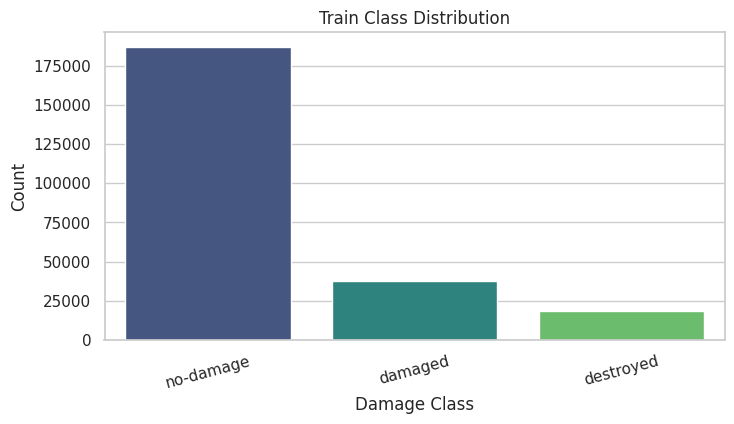

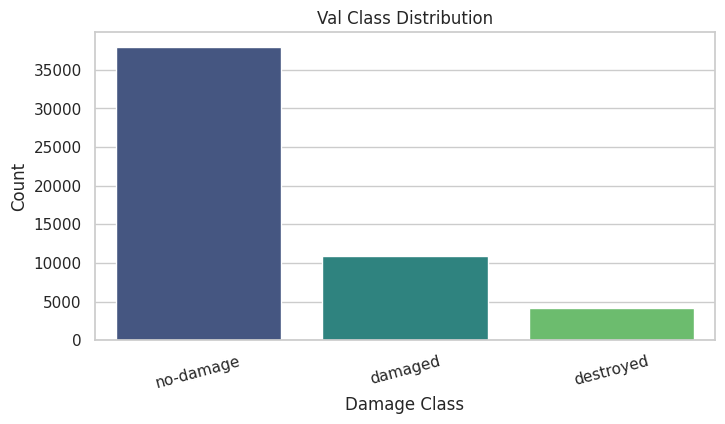

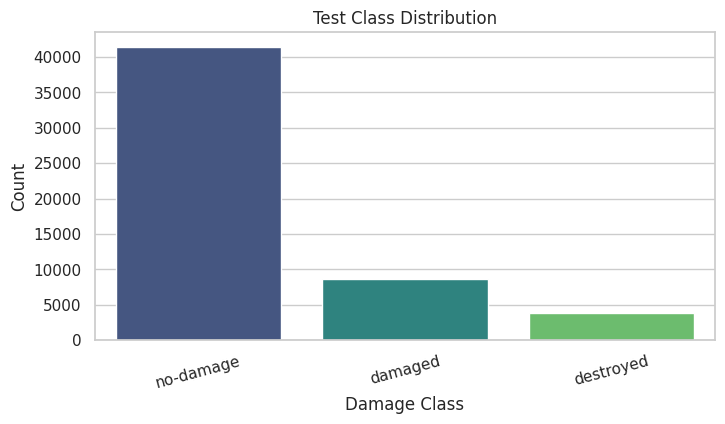

In [10]:
def plot_class_distribution(df: pd.DataFrame, title: str):
    plt.figure(figsize=(8, 4))
    order = CLASS_NAMES
    sns.countplot(data=df, x="label_name", order=order, palette="viridis")
    plt.title(title)
    plt.xlabel("Damage Class")
    plt.ylabel("Count")
    plt.xticks(rotation=15)
    plt.show()


plot_class_distribution(train_df_small, "Train Class Distribution")
plot_class_distribution(val_df, "Val Class Distribution")
plot_class_distribution(test_df, "Test Class Distribution")

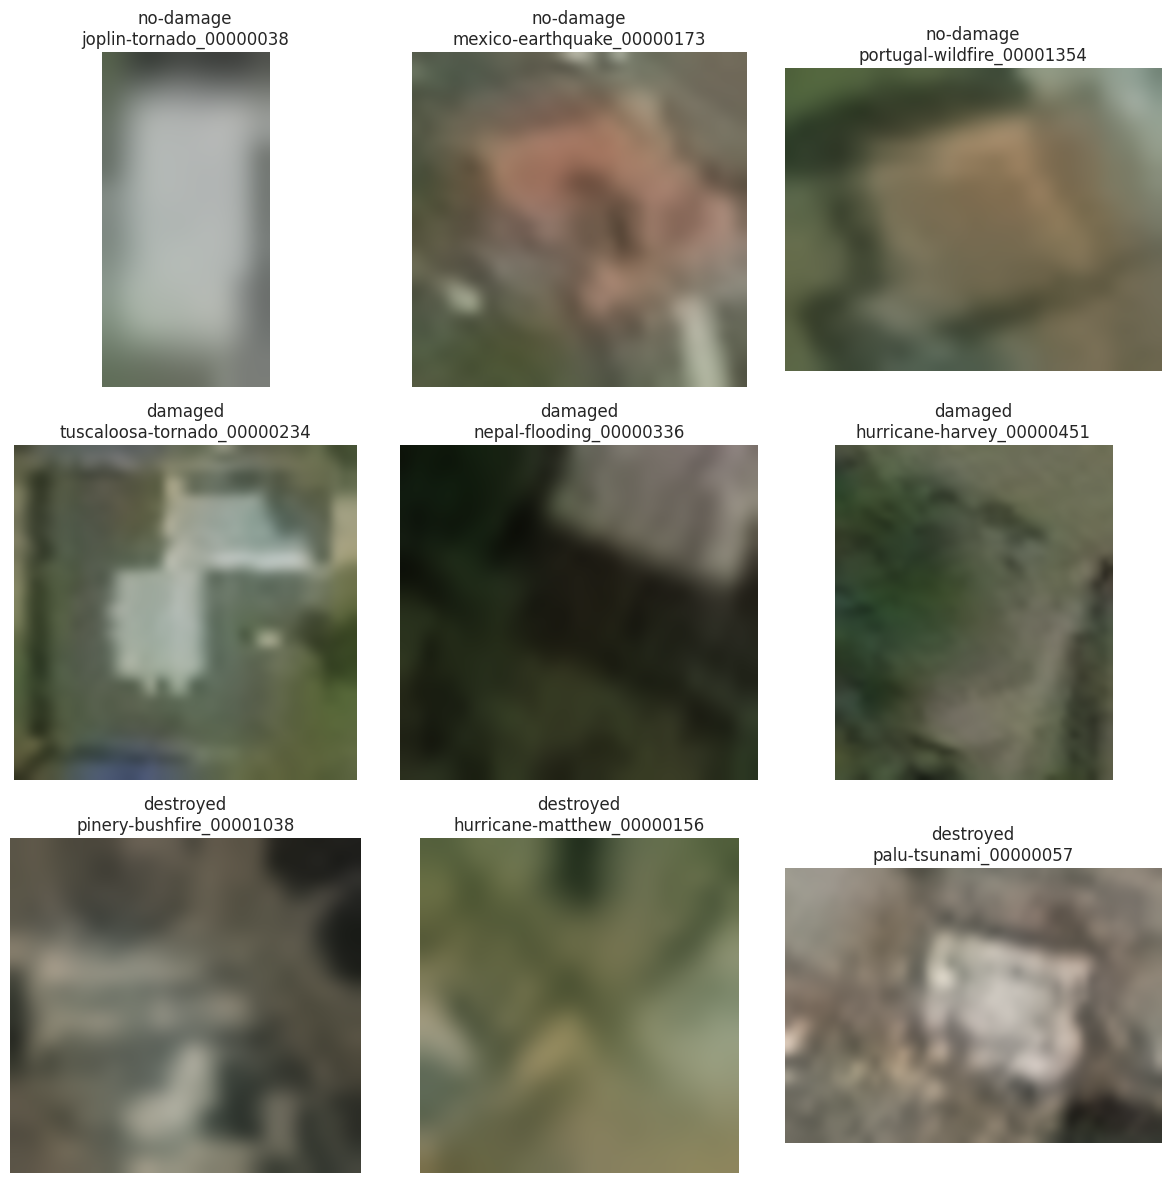

In [11]:
def show_random_building_crops(df: pd.DataFrame, samples_per_class: int = 3):
    fig, axes = plt.subplots(
        len(CLASS_NAMES),
        samples_per_class,
        figsize=(4 * samples_per_class, 4 * len(CLASS_NAMES))
    )

    if samples_per_class == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, class_name in enumerate(CLASS_NAMES):

        class_df = df[df["label_name"] == class_name]
        if len(class_df) == 0:
            continue

        sampled = class_df.sample(
            min(samples_per_class, len(class_df)),
            random_state=SEED
        ).reset_index(drop=True)

        for col_idx in range(samples_per_class):

            ax = axes[row_idx][col_idx]
            ax.axis("off")

            if col_idx >= len(sampled):
                continue

            row = sampled.iloc[col_idx]

            try:
                with rasterio.open(row["image_path"]) as src:
                    image = src.read([1, 2, 3]).transpose(1, 2, 0)

                x1, y1 = int(row["bbox_x1"]), int(row["bbox_y1"])
                x2, y2 = int(row["bbox_x2"]), int(row["bbox_y2"])

                crop = image[y1:y2, x1:x2]

                ax.imshow(crop, interpolation="bicubic")
                ax.set_title(f"{class_name}\n{row['image_id']}")

            except Exception as e:
                ax.text(0.5,0.5,f"Error\n{str(e)[:50]}",ha="center",va="center")

    plt.tight_layout()
    plt.show()

show_random_building_crops(train_df, samples_per_class=3)

## Dataset and Augmentations

The classifier uses building crops as inputs. We resize them to a fixed image size and apply moderate augmentation for training.


In [12]:
train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=12),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


class BuildingSeverityDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):

        row = self.df.iloc[idx]

        with rasterio.open(row["image_path"]) as src:
            image = src.read([1, 2, 3]).transpose(1, 2, 0)

        x1 = int(row["bbox_x1"])
        y1 = int(row["bbox_y1"])
        x2 = int(row["bbox_x2"])
        y2 = int(row["bbox_y2"])

        crop = image[y1:y2, x1:x2]
        crop = Image.fromarray(crop.astype(np.uint8))

        if self.transform:
            crop_tensor = self.transform(crop)
        else:
            crop_tensor = transforms.ToTensor()(crop)

        label = int(row["label_idx"])

        metadata = {
            "image_id": row["image_id"],
            "building_uid": row["building_uid"],
            "label_name": row["label_name"],
            "bbox": [x1, y1, x2, y2],
        }

        return crop_tensor, label, metadata


train_dataset = BuildingSeverityDataset(train_df_small, transform=train_transform)
val_dataset = BuildingSeverityDataset(val_df, transform=eval_transform)
test_dataset = BuildingSeverityDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## Model, Loss, and Metrics

- **Backbone:** EfficientNet-B0
- **Task:** 4-class building severity classification
- **Ignored target:** `un-classified`
- **Loss:** weighted cross-entropy
- **Primary metric:** macro F1-score


In [13]:
def build_model(num_classes: int):
    model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
    return model

model = build_model(num_classes=len(CLASS_NAMES)).to(DEVICE)
model

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [14]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 4,011,391


In [15]:
train_labels = train_df["label_idx"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("Class weights:", {CLASS_NAMES[i]: round(float(w), 4) for i, w in enumerate(class_weights.cpu().numpy())})

Class weights: {'no-damage': 0.4343, 'damaged': 2.1507, 'destroyed': 4.3059}


In [16]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

def format_metrics(metrics_dict):
    return {k: round(v, 4) for k, v in metrics_dict.items()}

## Training and Validation

The training loop saves the best checkpoint based on **validation macro F1**.


In [17]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    y_true, y_pred = [], []

    progress_bar = tqdm(loader, desc="Training",leave=False)

    for images, labels, _ in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(y_true, y_pred)

    return epoch_loss, epoch_metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    y_true, y_pred = [], []
    logits_list = []
    metadata_list = []

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    for images, labels, metadata in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

        logits_list.append(logits.cpu())

        metadata_list.extend(
            [
                {
                    "image_id": metadata["image_id"][i],
                    "building_uid": metadata["building_uid"][i],
                    "label_name": metadata["label_name"][i],
                    "bbox": [
                        int(metadata["bbox"][0][i]),
                        int(metadata["bbox"][1][i]),
                        int(metadata["bbox"][2][i]),
                        int(metadata["bbox"][3][i]),
                    ],
                }
                for i in range(len(metadata["image_id"]))
            ]
        )

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(y_true, y_pred)
    logits_tensor = torch.cat(logits_list, dim=0)

    return (epoch_loss, epoch_metrics, y_true, y_pred, logits_tensor, metadata_list,)

In [18]:
from IPython.display import clear_output, display

history = []
best_val_f1 = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_severity_classifier.pth"

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_metrics, _, _, _, _ = evaluate(model, val_loader, criterion,DEVICE)

    scheduler.step(val_metrics["macro_f1"])

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(epoch_record)

    # Save best model based on validation Macro F1
    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_macro_f1": best_val_f1,
                "class_names": CLASS_NAMES,
                "image_size": IMAGE_SIZE,
                "padding_ratio": PADDING_RATIO,
                "model_name": "efficientnet_b0",
            },
            best_checkpoint_path,
        )

        checkpoint_status = "✅ Saved Best Model"
    else:
        checkpoint_status = ""

    clear_output(wait=True)

    history_df = pd.DataFrame(history)

    display(
        history_df[
            [
                "epoch",
                "train_loss",
                "val_loss",
                "train_accuracy",
                "val_accuracy",
                "train_macro_precision",
                "val_macro_precision",
                "train_macro_recall",
                "val_macro_recall",
                "train_macro_f1",
                "val_macro_f1",
            ]].round(4))

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Best Macro F1: {best_val_f1:.4f} "
        f"{checkpoint_status}"
    )

print(f"\nTraining complete.")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")
print(f"Checkpoint saved at: {best_checkpoint_path}")

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_precision,val_macro_precision,train_macro_recall,val_macro_recall,train_macro_f1,val_macro_f1
0,1,0.7296,0.6081,0.6897,0.7391,0.5684,0.6184,0.7184,0.7415,0.6011,0.6508
1,2,0.4889,0.5152,0.7826,0.7798,0.6555,0.6676,0.7992,0.7992,0.7013,0.7079
2,3,0.4301,0.4457,0.8113,0.8197,0.6856,0.7175,0.8241,0.8202,0.7334,0.7558
3,4,0.3929,0.4418,0.8275,0.8193,0.7047,0.7179,0.8403,0.8261,0.7532,0.7574
4,5,0.3569,0.4407,0.8420,0.8174,0.7235,0.7209,0.8550,0.8262,0.7722,0.7586
5,6,0.3215,0.4734,0.8531,0.8149,0.7386,0.7103,0.8689,0.8240,0.7877,0.7506
6,7,0.2843,0.4882,0.8661,0.8097,0.7588,0.6962,0.8855,0.8261,0.8076,0.7384


Epoch 07/20 | Train Loss: 0.2843 | Val Loss: 0.4882 | Val Macro F1: 0.7384 | Best Macro F1: 0.7586 


Training:   0%|          | 0/1903 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [19]:
display(history_df[["epoch", "train_loss", "val_loss", "train_accuracy",
                    "val_accuracy", "train_macro_precision", "val_macro_precision",
                    "train_macro_recall", "val_macro_recall", "train_macro_f1",
                    "val_macro_f1"]].round(4))

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_precision,val_macro_precision,train_macro_recall,val_macro_recall,train_macro_f1,val_macro_f1
0,1,0.7296,0.6081,0.6897,0.7391,0.5684,0.6184,0.7184,0.7415,0.6011,0.6508
1,2,0.4889,0.5152,0.7826,0.7798,0.6555,0.6676,0.7992,0.7992,0.7013,0.7079
2,3,0.4301,0.4457,0.8113,0.8197,0.6856,0.7175,0.8241,0.8202,0.7334,0.7558
3,4,0.3929,0.4418,0.8275,0.8193,0.7047,0.7179,0.8403,0.8261,0.7532,0.7574
4,5,0.3569,0.4407,0.8420,0.8174,0.7235,0.7209,0.8550,0.8262,0.7722,0.7586
5,6,0.3215,0.4734,0.8531,0.8149,0.7386,0.7103,0.8689,0.8240,0.7877,0.7506
6,7,0.2843,0.4882,0.8661,0.8097,0.7588,0.6962,0.8855,0.8261,0.8076,0.7384


In [20]:
print(f"Best Validation Macro F1: {best_val_f1:.4f}")
print(f"Checkpoint saved at: {best_checkpoint_path}")

Best Validation Macro F1: 0.7586
Checkpoint saved at: /kaggle/working/notebook3_severity_outputs/checkpoints/best_severity_classifier.pth


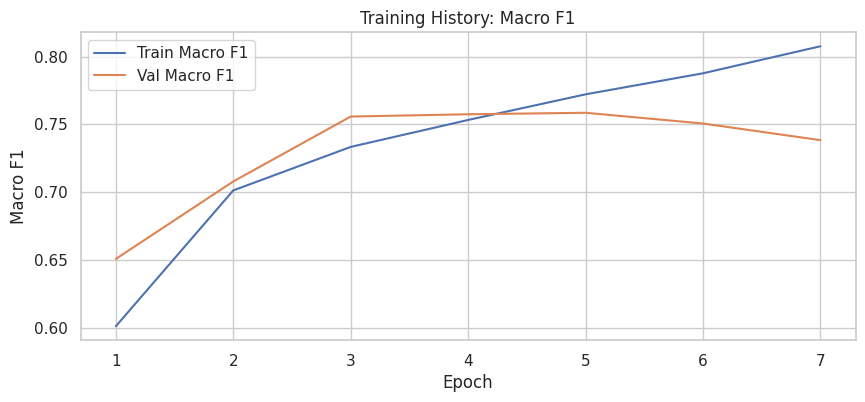

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training History: Macro F1")
plt.legend()
plt.show()

## Final Evaluation

We reload the best checkpoint and evaluate on validation and test splits. The most important reported metric is **macro F1-score**.


In [22]:
checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_loss, val_metrics, val_true, val_pred, val_logits, val_meta = evaluate(model, val_loader, criterion, DEVICE)
test_loss, test_metrics, test_true, test_pred, test_logits, test_meta = evaluate(model, test_loader, criterion, DEVICE)

print("Validation metrics:", format_metrics(val_metrics))
print("Test metrics:", format_metrics(test_metrics))

Validation:   0%|          | 0/416 [00:00<?, ?it/s]

Validation:   0%|          | 0/421 [00:00<?, ?it/s]

Validation metrics: {'accuracy': 0.8174, 'macro_precision': 0.7209, 'macro_recall': 0.8262, 'macro_f1': 0.7586}
Test metrics: {'accuracy': 0.8302, 'macro_precision': 0.7036, 'macro_recall': 0.8349, 'macro_f1': 0.7504}


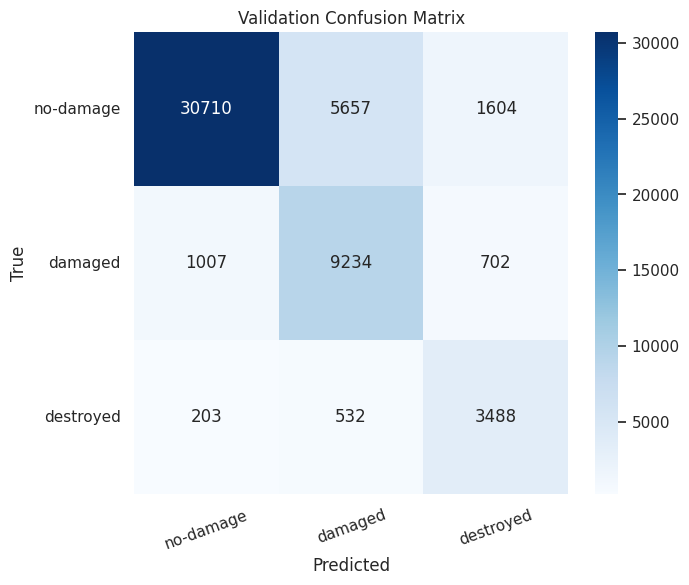

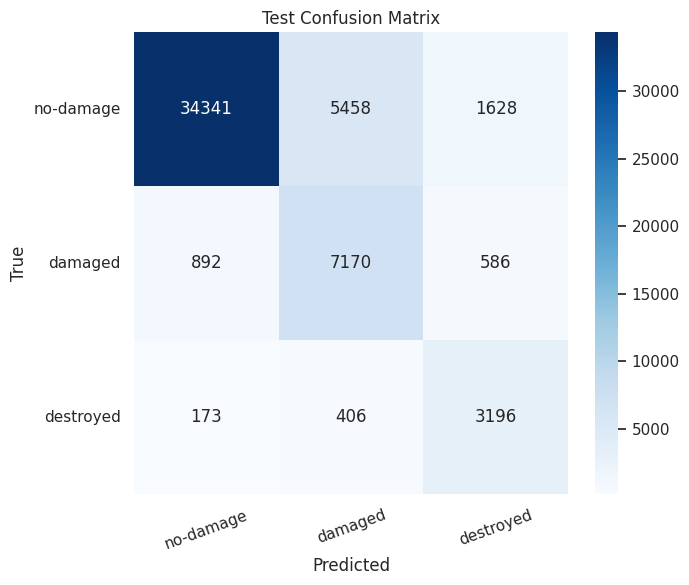

Validation classification report
              precision    recall  f1-score   support

   no-damage       0.96      0.81      0.88     37971
     damaged       0.60      0.84      0.70     10943
   destroyed       0.60      0.83      0.70      4223

    accuracy                           0.82     53137
   macro avg       0.72      0.83      0.76     53137
weighted avg       0.86      0.82      0.83     53137

Test classification report
              precision    recall  f1-score   support

   no-damage       0.97      0.83      0.89     41427
     damaged       0.55      0.83      0.66      8648
   destroyed       0.59      0.85      0.70      3775

    accuracy                           0.83     53850
   macro avg       0.70      0.83      0.75     53850
weighted avg       0.88      0.83      0.84     53850



In [23]:
def plot_confusion(y_true, y_pred, split_name: str):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)
    plt.show()
    return cm


val_cm = plot_confusion(val_true, val_pred, "Validation")
test_cm = plot_confusion(test_true, test_pred, "Test")

print("Validation classification report")
print(classification_report(val_true, val_pred, target_names=CLASS_NAMES, zero_division=0))

print("Test classification report")
print(classification_report(test_true, test_pred, target_names=CLASS_NAMES, zero_division=0))

## Confidence and Optional Uncertainty

We always save confidence scores. If enabled, Monte Carlo Dropout is used to estimate predictive uncertainty.


In [24]:
def softmax_confidence(logits: torch.Tensor):
    probs = torch.softmax(logits, dim=1)
    confidences, preds = probs.max(dim=1)
    return probs, preds, confidences

def build_prediction_dataframe(y_true,logits_tensor,metadata_list,split_name: str,):

    probs, preds, confidences = softmax_confidence(logits_tensor)

    rows = []

    for idx, meta in enumerate(metadata_list):

        rows.append(
            {
                "split": split_name,

                "image_id": meta["image_id"],
                "building_uid": meta["building_uid"],

                "true_label": CLASS_NAMES[y_true[idx]],
                "predicted_label": CLASS_NAMES[int(preds[idx].item())],

                "confidence": float(confidences[idx].item()),

                "bbox_x1": meta["bbox"][0],
                "bbox_y1": meta["bbox"][1],
                "bbox_x2": meta["bbox"][2],
                "bbox_y2": meta["bbox"][3],
            }
        )

    return pd.DataFrame(rows)

In [25]:
val_pred_df = build_prediction_dataframe(val_true, val_logits, val_meta, "val")
test_pred_df = build_prediction_dataframe(test_true, test_logits, test_meta, "test")

display(test_pred_df.head())

,split,image_id,building_uid,true_label,predicted_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,test,guatemala-volcano_00000003,88703461-a33d-4327-9244-a0d4e2242ede,damaged,damaged,0.844873,429,81,497,141
1,test,guatemala-volcano_00000003,e168e405-3479-44ee-849a-7af2ed32dee1,destroyed,destroyed,0.989405,224,306,257,324
2,test,guatemala-volcano_00000003,9f8f8916-b6c5-4fa8-ab64-c8fd86eca035,damaged,damaged,0.746089,561,234,624,299
3,test,guatemala-volcano_00000009,0bf9cbdc-3fa6-4afd-82ff-e40036f2f361,no-damage,no-damage,0.835187,341,674,443,763
4,test,guatemala-volcano_00000009,7e5c019d-44e9-4230-b916-b3fa4145873c,no-damage,no-damage,0.958715,259,746,411,925


## Grad-CAM Explainability

Grad-CAM is used only for **selected samples**, not every building crop. This keeps storage manageable while still giving strong explainability examples.


In [26]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor.cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    return image.permute(1, 2, 0).numpy()


def load_rgb_tif(path):

    with rasterio.open(path) as src:
        image = src.read([1, 2, 3])

    image = np.transpose(image, (1, 2, 0))
    if image.dtype != np.uint8:
        image = image.astype(np.float32)
        image = (255 * (image - image.min()) / (image.max() - image.min() + 1e-8)).astype(np.uint8)

    return Image.fromarray(image)


def select_gradcam_examples(pred_df: pd.DataFrame, samples_per_class: int = 3,):

    selected_frames = []
    correct_df = pred_df[pred_df["true_label"] == pred_df["predicted_label"]].copy()

    for class_name in CLASS_NAMES:
        class_examples = correct_df[(correct_df["true_label"] == class_name) &
        (correct_df["confidence"] > 0.9)]

        class_examples = class_examples.sample(n=min(samples_per_class, len(class_examples)),random_state=42)
        selected_frames.append(class_examples)

    selected_df = pd.concat(selected_frames,ignore_index=True )

    return selected_df


selected_gradcam_df = (select_gradcam_examples(test_pred_df,samples_per_class=3))

print(f"Selected {len(selected_gradcam_df)} GradCAM samples")

display(selected_gradcam_df[["true_label","predicted_label", "confidence"]])

Selected 9 GradCAM samples


,true_label,predicted_label,confidence
0,no-damage,no-damage,0.999995
1,no-damage,no-damage,0.951646
2,no-damage,no-damage,1.000000
3,damaged,damaged,0.992300
4,damaged,damaged,0.918872
5,damaged,damaged,0.925904
6,destroyed,destroyed,0.999488
7,destroyed,destroyed,0.944916
8,destroyed,destroyed,0.997092


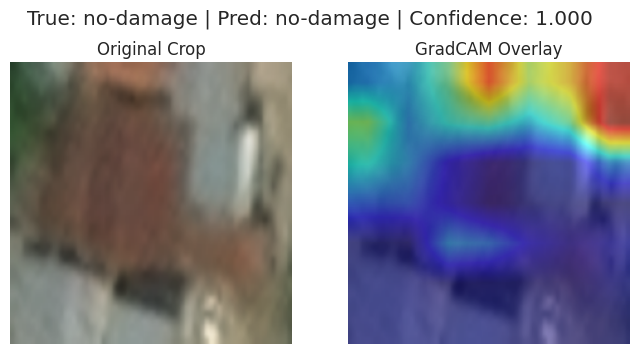

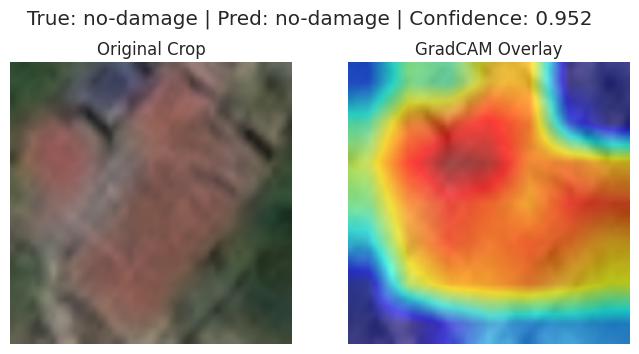

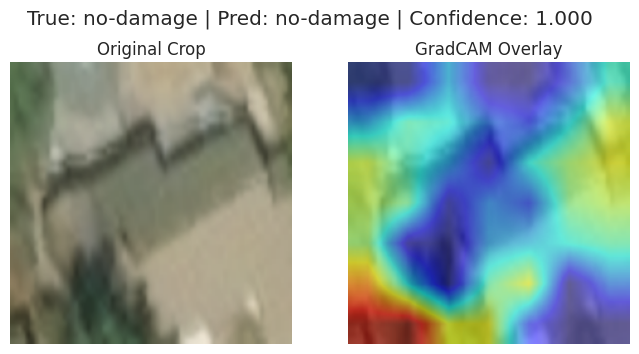

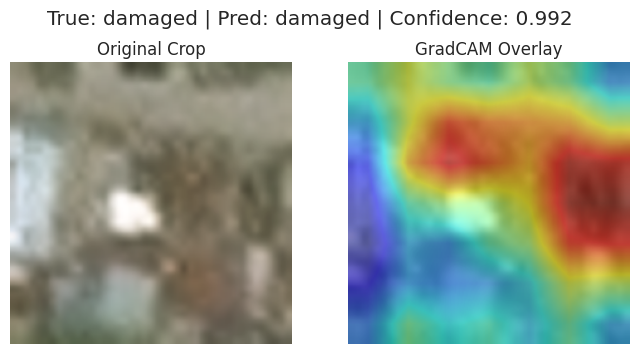

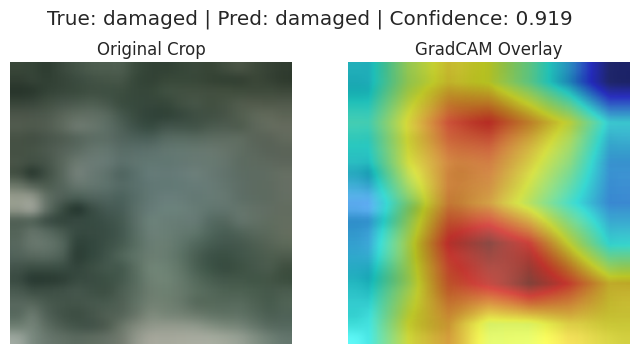

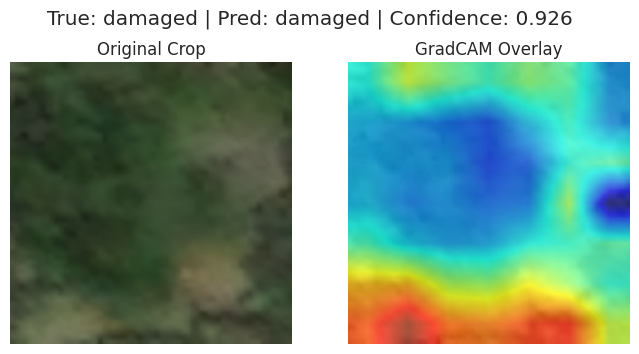

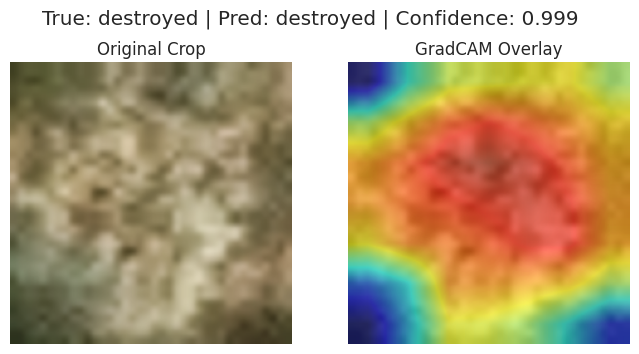

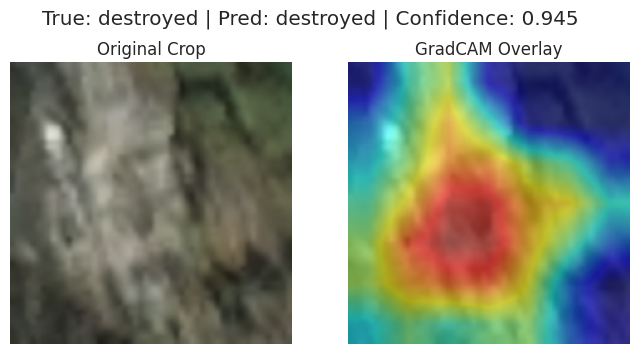

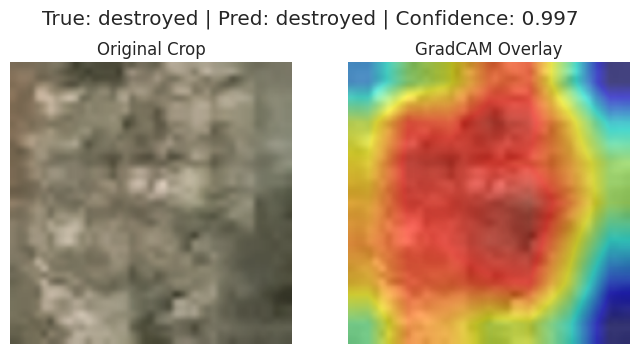

Saved 9 GradCAM images


In [27]:
def get_dataset_row_by_keys(df: pd.DataFrame,image_id: str,building_uid: str,):
    match = df[(df["image_id"] == image_id) & (df["building_uid"] == building_uid)]

    if len(match) == 0:
        return None

    return match.iloc[0]


def generate_gradcam_examples(model,source_df: pd.DataFrame,selected_df: pd.DataFrame,output_dir: Path,):

    target_layers = [model.blocks[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    saved_paths = []

    output_dir.mkdir(parents=True,exist_ok=True)

    for idx, pred_row in (selected_df.iterrows()):

        source_row = (
            get_dataset_row_by_keys(
                source_df,
                pred_row["image_id"],
                pred_row["building_uid"]
            )
        )

        if source_row is None:
            continue

        image = load_rgb_tif(source_row["image_path"])

        crop = image.crop(
            (
                source_row["bbox_x1"],
                source_row["bbox_y1"],
                source_row["bbox_x2"],
                source_row["bbox_y2"],
            )
        )

        input_tensor = (eval_transform(crop).unsqueeze(0).to(DEVICE))

        grayscale_cam = cam(input_tensor=input_tensor)[0]

        rgb_image = (
            np.array(
                crop.resize(
                    (
                        IMAGE_SIZE,
                        IMAGE_SIZE
                    )
                )
            ).astype(np.float32)
            / 255.0
        )

        visualization = (show_cam_on_image(rgb_image,grayscale_cam,use_rgb=True))

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))

        ax[0].imshow(rgb_image)
        ax[0].set_title("Original Crop")
        ax[0].axis("off")

        ax[1].imshow(visualization)
        ax[1].set_title("GradCAM Overlay")
        ax[1].axis("off")

        fig.suptitle(
            f"True: {pred_row['true_label']} | "
            f"Pred: {pred_row['predicted_label']} | "
            f"Confidence: {pred_row['confidence']:.3f}"
        )

        save_path = (output_dir / f"gradcam_{idx:02d}.png")

        plt.savefig(save_path, bbox_inches="tight", dpi=200)
        plt.show()
        plt.close()
        saved_paths.append(str(save_path))

    return saved_paths


gradcam_paths = (generate_gradcam_examples(
    model,
    test_df,
    selected_gradcam_df,
    GRADCAM_DIR
    ))

print(f"Saved {len(gradcam_paths)} GradCAM images")

## Save Final Artifacts

This notebook saves all important artifacts so the classifier can be reused later in:
- GitHub cleanup and refactoring
- Streamlit or frontend deployment
- Notebook 4 disaster report generation


In [29]:
import zipfile
import shutil

OUTPUT_DIR = Path("notebook2_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Model
torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pth")

# Class Mapping
class_mapping = {idx: label for idx, label in enumerate(CLASS_NAMES)}

with open(OUTPUT_DIR / "class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=2)


# Predictions
val_pred_df.to_csv(OUTPUT_DIR / "severity_predictions_val.csv", index=False)
test_pred_df.to_csv(OUTPUT_DIR / "severity_predictions_test.csv", index=False)

val_pred_df.to_json(OUTPUT_DIR / "severity_predictions_val.json", orient="records", indent=2)
test_pred_df.to_json(OUTPUT_DIR / "severity_predictions_test.json", orient="records", indent=2)


# Confusion Matrix
pd.DataFrame(val_cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / "validation_confusion_matrix.csv")
pd.DataFrame(test_cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / "test_confusion_matrix.csv")

plt.figure(figsize=(7, 6))
sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(OUTPUT_DIR / "validation_confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(7, 6))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(OUTPUT_DIR / "test_confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.close()


# Copy GradCAM Images
SOURCE_GRADCAM_DIR = Path("/kaggle/working/notebook3_severity_outputs/gradcam")

gradcam_output_dir = OUTPUT_DIR / "gradcam_images"
gradcam_output_dir.mkdir(exist_ok=True)

copied = 0

for img_file in SOURCE_GRADCAM_DIR.glob("*.png"):
    shutil.copy(img_file, gradcam_output_dir / img_file.name)
    copied += 1

print(f"Copied {copied} GradCAM images")


zip_path = "notebook2_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in OUTPUT_DIR.rglob("*"):
        zipf.write(file, arcname=file.relative_to(OUTPUT_DIR))

print("=" * 60)
print("Artifacts saved successfully")
print(f"Folder : {OUTPUT_DIR}")
print(f"ZIP    : {zip_path}")
print("=" * 60)

Copied 9 GradCAM images
Artifacts saved successfully
Folder : notebook2_outputs
ZIP    : notebook2_outputs.zip


## Final Notes

- The current notebook uses **annotated building polygons** to obtain building crops.
- It does **not** detect buildings from raw imagery yet.
- A future extension can add a learned building detection model for full end-to-end automation.
- Notebook 4 can later consume:
  - building-level severity prediction CSV / JSON
  - confidence and uncertainty scores
  - selected Grad-CAM examples
